# Main

In [37]:
##########################################################################
import os

# set the environment variable to control the number of threads
# NEEDS TO BE DONE BEFORE CCL IS IMPORTED
original_omp_num_threads = os.environ.get('OMP_NUM_THREADS', None)
os.environ['OMP_NUM_THREADS'] = '1'

# Generic
import pandas as pd
import numpy as np
import scipy
from itertools import islice, cycle
import math
import sys
from scipy.integrate import odeint
from joblib import Parallel, delayed
import itertools
from importlib import reload
from functools import lru_cache
import scipy.integrate
import baccoemu
import subprocess
import multiprocessing

# cosmology
import pyccl as ccl
from astropy.io import fits
import yaml
import sacc
import time

# Generate data sets
from sklearn.datasets import make_blobs
import sklearn
#print(sklearn.__version__) # should be 1.3.2

# PCA
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# SRD Binning
import srd_redshift_distributions as srd
import binning

# Data Visualization
import matplotlib.pyplot as plt
from tabulate import tabulate
import matplotlib.patches as mpatches
import matplotlib
#import seaborn as sns

# MCMC
import emcee
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import corner
from chainconsumer import ChainConsumer, Chain, make_sample
from IPython.display import display, Math
from multiprocessing import Pool, cpu_count
from tqdm import tqdm
import gc

# Profiling
import cProfile
import pstats
from IPython.display import HTML

# nDGP NL and lin Pk
from nDGPemu import BoostPredictor

# f(R) emu (eMANTIS)
from emantis import FofrBoost

# Initialise and emulator instance.
emu_fR = FofrBoost()

In [38]:
!which python

/home/c2042999/PCA_env/3.8.10/bin/python


In [39]:
print(emcee.__version__)
print(ccl.__version__)

3.1.6
3.0.0


In [40]:
from LikelihoodFuncts_PCADR_muSigma import *

In [41]:
# Define cosmology
cosmo_universe = ccl.Cosmology(Omega_c = 0.269619, 
                          Omega_b = 0.050041,
                          h = 0.6688,
                          n_s = 0.9626,
                          A_s = 2.092e-9)


In [42]:
# GET F(R) LINEAR POWER SPECTRUM, fiducial
##########################
idx_mdom = 0
a_solver = np.linspace(1/50,1.1,50)
k_solver = np.logspace(-5,4,200)

Soln = odeint(solverGrowth_nDGP, [a_solver[0], (E(cosmo_universe, a_solver[0])*a_solver[0]**3)], a_solver,\
              args=(cosmo_universe,[0,0,0,0,0]), mxstep=int(1e4))

Delta_GR = Soln.T[0]/Soln.T[0][idx_mdom]

Delta = []
for i in range(len(k_solver)):
    Soln = odeint(solverGrowth_fR, [a_solver[0], (E(cosmo_universe, a_solver[0])*a_solver[0]**3)], a_solver, \
                  args=(cosmo_universe,[0,1e-5,0,0,0], k_solver[i]), mxstep=int(1e4))
    
    Delta_i = Soln.T[0]
    Delta.append(Delta_i/Delta_i[idx_mdom])

Delta = np.array(Delta)

# Get Pk linear in GR

interp_fR_Pk = scipy.interpolate.RegularGridInterpolator((k_solver,a_solver), (Delta / Delta_GR)**2,bounds_error=False, fill_value=1.0)
##########################

In [43]:
##########################################################################
#### Train the emulators ####
# Define the redshift interval and forecast years
redshift_range = np.linspace(0.01, 3.5, 500)
forecast_years = ["1", "10"]  # Assuming integers are appropriate

# Create a dictionary to store the redshift distributions
# for each forecast year and galaxy sample
redshift_distribution = {
    "sources": {},
    "lenses": {}
}

for year in forecast_years:
    source_dist = srd.SRDRedshiftDistributions(redshift_range, 
                                               galaxy_sample="source_sample",
                                               forecast_year=year)
    lens_dist = srd.SRDRedshiftDistributions(redshift_range, 
                                             galaxy_sample="lens_sample",
                                             forecast_year=year)

    redshift_distribution["sources"][year] = source_dist.get_redshift_distribution(normalised=True,
                                                                                   save_file=False)
    redshift_distribution["lenses"][year] = lens_dist.get_redshift_distribution(normalised=True,
                                                                                save_file=False)

# Uncomment to check if the dictionary is populated correctly
# print(redshift_distribution["sources"].keys())


bins = {
    "sources": {},
    "lenses": {}
}

# Perform the binning procedure
for year in forecast_years:
    bins["sources"][year] = binning.Binning(redshift_range, 
                                            redshift_distribution["sources"][year],
                                            year).source_bins(normalised=True,
                                                              save_file=False)
    bins["lenses"][year] = binning.Binning(redshift_range, 
                                           redshift_distribution["lenses"][year],
                                           year).lens_bins(normalised=True,
                                                           save_file=False)


#(5, 256)
Binned_distribution_lens = [list(bins["lenses"]["1"].items())[0][1]]
for i in range(4):
    Binned_distribution_lens = np.append(Binned_distribution_lens,\
               [list(bins["lenses"]["1"].items())[i+1][1]], axis=0)

Binned_distribution_source = [list(bins["sources"]["1"].items())[0][1]]
for i in range(4):
    Binned_distribution_source = np.append(Binned_distribution_source,\
               [list(bins["sources"]["1"].items())[i+1][1]], axis=0)


Bias_distribution_fiducial = np.array([1.562362*np.ones(len(redshift_range)),
                             1.732963*np.ones(len(redshift_range)),
                             1.913252*np.ones(len(redshift_range)),
                             2.100644*np.ones(len(redshift_range)),
                             2.293210*np.ones(len(redshift_range))])

binned_ell_test = bin_ell_kk(20, 1478.5, 13, Binned_distribution_source)

P_delta2D_GR_lin_universe = Get_Pk2D_obj_kk_GR_lin(cosmo_universe)
P_delta2D_GR_nl_universe = Get_Pk2D_obj_kk_GR_nl(cosmo_universe)

mockdata_test = Cell(binned_ell_test, \
                cosmo_universe, redshift_range , Binned_distribution_source,Binned_distribution_lens,Bias_distribution_fiducial,[0.2,1e-5,1,0,0],\
                Get_Pk2D_obj(P_delta2D_GR_nl_universe,interp_fR_Pk,cosmo_universe, [0.2,1e-5,1,0,0], linear=False, gravity_model="f(R)"),tracer1_type="k", tracer2_type="k")

mockdata_test = Cell(binned_ell_test, \
                cosmo_universe, redshift_range , Binned_distribution_source,Binned_distribution_lens,Bias_distribution_fiducial,[0.2,1e-5,1,0,0],\
                Get_Pk2D_obj(P_delta2D_GR_nl_universe,interp_fR_Pk,cosmo_universe, [0.2,1e-5,1,0,0], linear=False, gravity_model="nDGP"),tracer1_type="k", tracer2_type="k")


In [44]:
value1 = [cosmo_universe["Omega_c"], 0.0, 0.0,cosmo_universe["A_s"]*1e9, cosmo_universe["h"],\
          cosmo_universe["n_s"],cosmo_universe["Omega_b"]*cosmo_universe["h"]**2,\
         Bias_distribution_fiducial[0][0], Bias_distribution_fiducial[1][0],\
         Bias_distribution_fiducial[2][0],Bias_distribution_fiducial[3][0],\
         Bias_distribution_fiducial[4][0]]

In [45]:
#### Define log likelihood #####
def log_likelihood(theta, Data, L_ch_inv,Data_fsigma8):
    Omega_c, mu0,Sigma0, A_s1e9, h, n_s, wb, b1, b2, b3, b4, b5 = theta 
    Bias_distribution = np.array([b1*np.ones(len(z)),
                             b2*np.ones(len(z)),
                             b3*np.ones(len(z)),
                             b4*np.ones(len(z)),
                             b5*np.ones(len(z))])
    #h = cosmo_universe["h"]
    #A_s = cosmo_universe["A_s"]
    A_s = A_s1e9*1e-9
    #n_s = cosmo_universe["n_s"]
    MGparams = [0.2,1e-4,1.0,mu0, Sigma0]

    cosmo = ccl.Cosmology(Omega_c = Omega_c, 
                      Omega_b = wb/h**2,
                      h = h,
                      n_s = n_s,
                      A_s = A_s)

    
    return loglikelihood(Data, cosmo, MGparams, L_ch_inv,Bias_distribution,Data_fsigma8)

#### Get Planck priors #####
sampler_Planck_arr = np.load("Prior_Planck_arr.npy")
mu_prior = [cosmo_universe['n_s'], cosmo_universe["Omega_b"]*cosmo_universe["h"]**2]
cov_prior = np.cov(sampler_Planck_arr.T)

#### Define log prior #####
def log_prior(theta):
    Omega_c, mu0,Sigma0, A_s1e9, h, n_s, wb, b1, b2, b3, b4, b5 = theta
    
    #flat priors
    if not (0.28 < Omega_c + wb/h**2 < 0.36  and\
            -1.5 < mu0 < 1.5 and -1.5 < Sigma0 < 1.5 and mu0 <= 2*Sigma0 + 1.0 \
            and 1.7 < A_s1e9 < 2.5 and 0.92 < n_s < 1 and 0.61 < h < 0.73 and 0.04 < wb/h**2 < 0.06 \
           and 0.8 < b1 < 3.0 and 0.8 < b2 < 3.0 and 0.8 < b3 < 3.0 and 0.8 < b4 < 3.0 and 0.8 < b5 < 3.0):
        return -np.inf

    gauss_funct = scipy.stats.multivariate_normal(mu_prior, cov_prior)

    return gauss_funct.logpdf([n_s, wb])


In [46]:
### Load and collect the data for likelihood
#npzfile = np.load("../Biases_parametrization/Data_storage_fR.npz")
npzfile = np.load("Data_storage_fR_partial.npz")
npzfile_GR = np.load("../Parameter_inference_GR/Data_storage_GR.npz")

C_ell_data_mock = [npzfile['C_ell_data'],npzfile['ell_data'],npzfile['z'],npzfile['Binned_distribution_source'],\
                    npzfile['Binned_distribution_lens'],20,1478.5,13]

Data_fsigma8= [npzfile['z_eff_fsigma8'], npzfile['fsigma8_data'],np.matrix(npzfile['invcov_fsigma8'])]

L_choleski_inv = np.matrix(npzfile_GR['L_ch_inv'])

gauss_invcov_rotated = np.matrix(npzfile_GR['Inverse_cov'])
z = npzfile['z']

/tmp/ipykernel_1592938/3443581952.py:9: PendingDeprecationWarning: the matrix subclass is not the recommended way to represent matrices or deal with linear algebra (see https://docs.scipy.org/doc/numpy/user/numpy-for-matlab-users.html). Please adjust your code to use regular ndarray.
  Data_fsigma8= [npzfile['z_eff_fsigma8'], npzfile['fsigma8_data'],np.matrix(npzfile['invcov_fsigma8'])]
/tmp/ipykernel_1592938/3443581952.py:11: PendingDeprecationWarning: the matrix subclass is not the recommended way to represent matrices or deal with linear algebra (see https://docs.scipy.org/doc/numpy/user/numpy-for-matlab-users.html). Please adjust your code to use regular ndarray.
  L_choleski_inv = np.matrix(npzfile_GR['L_ch_inv'])
/tmp/ipykernel_1592938/3443581952.py:13: PendingDeprecationWarning: the matrix subclass is not the recommended way to represent matrices or deal with linear algebra (see https://docs.scipy.org/doc/numpy/user/numpy-for-matlab-users.html). Please adjust your code to use re

## Tests

In [14]:
"""Test C_kk(ell) function"""

binned_ell = bin_ell_kk(20, 1478.5, 13, Binned_distribution_source)
"""nDGP"""
# find C_ell for non-linear matter power spectrum
start = time.time()
testdata = Cell(binned_ell, \
                cosmo_universe, z , Binned_distribution_source,Binned_distribution_lens,Bias_distribution_fiducial,[0.2,0,0,0,0],\
                Get_Pk2D_obj(P_delta2D_GR_nl_universe,interp_fR_Pk,cosmo_universe, [0.2,0,0,0,0], linear=False, gravity_model="nDGP"), tracer1_type="k", tracer2_type="k")

print("time1 = ", time.time() - start)

ell_testdata = testdata[0]
D_testdata_kk = testdata[1]

D_testdata_kk = (np.array(D_testdata_kk)).flatten()

start = time.time()
testdata_lin = Cell(binned_ell, \
                cosmo_universe, z , Binned_distribution_source,Binned_distribution_lens,Bias_distribution_fiducial,[0.2,0,0,0,0],\
                Get_Pk2D_obj(P_delta2D_GR_lin_universe,interp_fR_Pk,cosmo_universe, [0.2,0,0,0,0], linear=True, gravity_model="nDGP"),tracer1_type="k", tracer2_type="k")

print("time2 = ", time.time() - start)

D_testdata_lin_kk = testdata_lin[1]
D_testdata_lin_kk = (np.array(D_testdata_lin_kk)).flatten()

del testdata, testdata_lin

"""fR"""
# find C_ell for non-linear matter power spectrum
start = time.time()
testdata_fR = Cell(binned_ell, \
                cosmo_universe, z , Binned_distribution_source,Binned_distribution_lens,Bias_distribution_fiducial,[0.2,1e-5,1,0,0],\
                Get_Pk2D_obj(P_delta2D_GR_nl_universe,interp_fR_Pk,cosmo_universe, [0.2,1e-5,1,0,0], linear=False, gravity_model="f(R)"),tracer1_type="k", tracer2_type="k")

print("time3 = ", time.time() - start)

ell_testdata_fR = testdata_fR[0]
D_testdata_kk_fR = testdata_fR[1]

D_testdata_kk_fR = (np.array(D_testdata_kk_fR)).flatten()

start = time.time()

testdata_lin_fR = Cell(binned_ell, \
                cosmo_universe, z , Binned_distribution_source,Binned_distribution_lens,Bias_distribution_fiducial,[0.2,1e-5,1,0,0],\
                Get_Pk2D_obj(P_delta2D_GR_lin_universe,interp_fR_Pk,cosmo_universe,[0.2,1e-5,1,0,0], linear=True, gravity_model="f(R)"),tracer1_type="k", tracer2_type="k")

print("time4 = ", time.time() - start)

D_testdata_lin_kk_fR = testdata_lin_fR[1]
D_testdata_lin_kk_fR = (np.array(D_testdata_lin_kk_fR)).flatten()

del testdata_fR, testdata_lin_fR

"""GR"""
# find C_ell for non-linear matter power spectrum
start = time.time()
testdata_GR = Cell(binned_ell, \
                cosmo_universe, z , Binned_distribution_source,Binned_distribution_lens,Bias_distribution_fiducial,[0.2,1e-5,1,0,0],\
                P_delta2D_GR_nl_universe,tracer1_type="k", tracer2_type="k")
print("time5 = ", time.time() - start)

D_testdata_GR_kk = testdata_GR[1]
D_testdata_GR_kk = (np.array(D_testdata_GR_kk)).flatten()

start = time.time()
testdata_GR_lin = Cell(binned_ell, \
                cosmo_universe, z , Binned_distribution_source,Binned_distribution_lens,Bias_distribution_fiducial,[0.2,1e-5,1,0,0],\
                P_delta2D_GR_lin_universe,tracer1_type="k", tracer2_type="k")
print("time6 = ", time.time() - start)

D_testdata_GR_lin_kk = testdata_GR_lin[1]
D_testdata_GR_lin_kk = (np.array(D_testdata_GR_lin_kk)).flatten()

del testdata_GR, testdata_GR_lin

time1 =  0.18581891059875488
time2 =  0.22068214416503906
time3 =  0.20567584037780762
time4 =  0.0793156623840332
time5 =  0.055861711502075195
time6 =  0.057959556579589844


(195,)


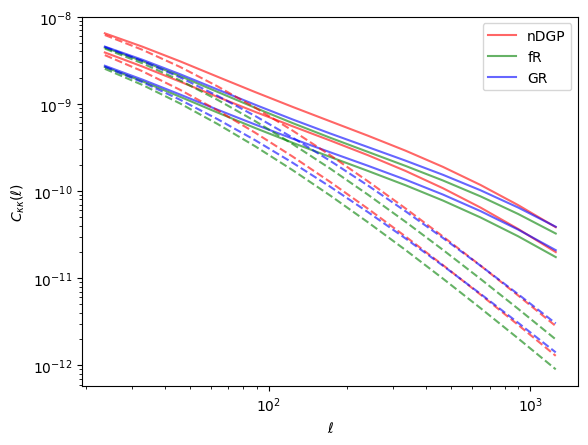

In [15]:
"""Plots: Test C_kk(ell) function"""

ell_bin_number = 13
print(D_testdata_kk.shape)


for j in range(2):
    plt.plot(ell_testdata[0:ell_bin_number], D_testdata_kk[j*ell_bin_number:(j+1)*ell_bin_number], "r", alpha= 0.6)
    plt.plot(ell_testdata[0:ell_bin_number], D_testdata_GR_kk[j*ell_bin_number:(j+1)*ell_bin_number], "g", alpha= 0.6)
    plt.plot(ell_testdata[0:ell_bin_number], D_testdata_kk_fR[j*ell_bin_number:(j+1)*ell_bin_number], "b", alpha= 0.6)
for j in range(2):
    plt.plot(ell_testdata[0:ell_bin_number], D_testdata_lin_kk[j*ell_bin_number:(j+1)*ell_bin_number], "r--", alpha= 0.6)
    plt.plot(ell_testdata[0:ell_bin_number], D_testdata_GR_lin_kk[j*ell_bin_number:(j+1)*ell_bin_number], "g--", alpha= 0.6)
    plt.plot(ell_testdata[0:ell_bin_number], D_testdata_lin_kk_fR[j*ell_bin_number:(j+1)*ell_bin_number], "b--", alpha= 0.6)


plt.xlabel(r'$\ell$')
plt.ylabel(r'$C_{\kappa\kappa}(\ell)$')
plt.legend(["nDGP", "fR","GR"])
plt.xscale('log')
plt.yscale('log')
plt.show()

<>:7: DeprecationWarning: invalid escape sequence '\e'
<>:8: DeprecationWarning: invalid escape sequence '\e'
<>:7: DeprecationWarning: invalid escape sequence '\e'
<>:8: DeprecationWarning: invalid escape sequence '\e'
/tmp/ipykernel_1592938/4073861087.py:7: DeprecationWarning: invalid escape sequence '\e'
  plt.xlabel("$\ell$",fontsize=16)
/tmp/ipykernel_1592938/4073861087.py:8: DeprecationWarning: invalid escape sequence '\e'
  plt.ylabel("$C^{ij}_{AB}(\ell)$",fontsize=16)


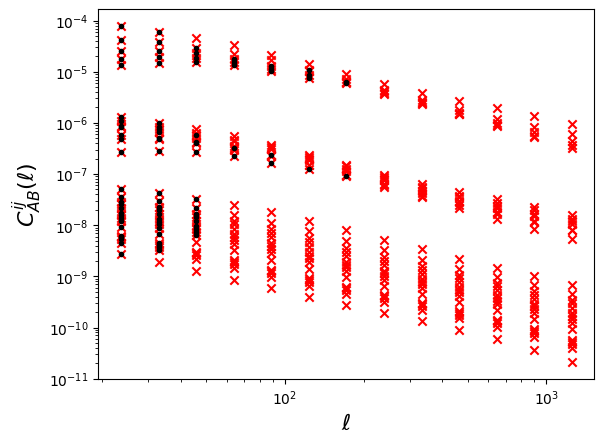

In [16]:
plt.scatter(npzfile['ell_data'],npzfile['C_ell_data'], color="r", marker='x')

for i in range(351):
    if gauss_invcov_rotated[0,i] !=0:
        plt.scatter(npzfile['ell_data'][i],npzfile['C_ell_data'][i], color="k", marker='.')

plt.xlabel("$\ell$",fontsize=16)
plt.ylabel("$C^{ij}_{AB}(\ell)$",fontsize=16)
plt.xscale("log")
plt.yscale("log")
#plt.savefig("LinearScaleCuts.pdf", bbox_inches='tight')


(351, 351)


/home/c2042999/PCA_project/Parameter_inference_fR/LikelihoodFuncts_PCADR_muSigma.py:1486: RuntimeWarning: invalid value encountered in divide
  return cov/np.outer(sig, sig)


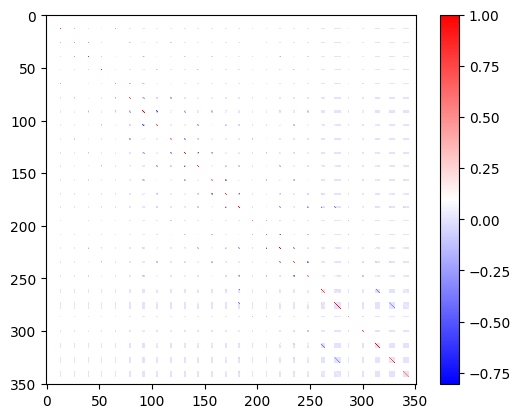

In [17]:
print(gauss_invcov_rotated.shape)
plt.imshow(cov2corr(gauss_invcov_rotated), origin='upper',  cmap='bwr')

plt.colorbar()
plt.show()

# Main

In [47]:
## add C_ell_data_mock, L_choleski_inv, Data_fsigma8
#### Define log probability #####
def log_probability(theta):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, C_ell_data_mock, L_choleski_inv,Data_fsigma8)

In [60]:
# Test likelihoods look reasonable

command = 'python Likelihood_fR_parallel_mpi_StandardCuts_test.py'
os.system(command)

/home/c2042999/PCA_env/3.8.10/lib/python3.10/site-packages/nDGPemu/emulator.py:5: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  from pkg_resources import resource_stream
/home/c2042999/PCA_env/3.8.10/lib/python3.10/site-packages/pkg_resources/__init__.py:2871: DeprecationWarning: Deprecated call to `pkg_resources.declare_namespace('sphinxcontrib')`.
Implementing implicit namespace packages (as specified in PEP 420) is preferred to `pkg_resources.declare_namespace`. See https://setuptools.pypa.io/en/latest/references/keywords.html#keyword-namespace-packages
  declare_namespace(pkg)
/home/c2042999/PCA_env/3.8.10/lib/python3.10/site-packages/nDGPemu/emulator.py:43: DeprecationWarning: Use of .. or absolute path in a resource path is not allowed and will raise exceptions in a future release.
  self.model = joblib.load(resource_stream('nDGPemu','/cache/nDGPemu_LC_k5_woSN_PCA3_z2.joblib'))
/home/c2042999/PCA_env/3.8.1

Loading model and related data
lp fid=  [[-10.75852407]]
lp max=  [[-47.33098377]]


0

In [58]:
# Test likelihoods look reasonable
#lp fid=  [[-11.69001091]]
#lp random=  [[-16.89314804]]

command = 'python Likelihood_fR_parallel_mpi_noparam_PCACuts_test.py'
os.system(command)

/home/c2042999/PCA_env/3.8.10/lib/python3.10/site-packages/nDGPemu/emulator.py:5: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  from pkg_resources import resource_stream
/home/c2042999/PCA_env/3.8.10/lib/python3.10/site-packages/pkg_resources/__init__.py:2871: DeprecationWarning: Deprecated call to `pkg_resources.declare_namespace('sphinxcontrib')`.
Implementing implicit namespace packages (as specified in PEP 420) is preferred to `pkg_resources.declare_namespace`. See https://setuptools.pypa.io/en/latest/references/keywords.html#keyword-namespace-packages
  declare_namespace(pkg)
/home/c2042999/PCA_env/3.8.10/lib/python3.10/site-packages/nDGPemu/emulator.py:43: DeprecationWarning: Use of .. or absolute path in a resource path is not allowed and will raise exceptions in a future release.
  self.model = joblib.load(resource_stream('nDGPemu','/cache/nDGPemu_LC_k5_woSN_PCA3_z2.joblib'))
/home/c2042999/PCA_env/3.8.1

Loading model and related data
Training the emulator at aexp=0.3333... done.
Training the emulator at aexp=0.3650... done.
Training the emulator at aexp=0.4000... done.
Training the emulator at aexp=0.4167... 

Traceback (most recent call last):
  File "/home/c2042999/PCA_project/Parameter_inference_fR/Likelihood_fR_parallel_mpi_noparam_PCACuts_test.py", line 194, in <module>
    Get_Pk2D_obj(P_delta2D_GR_nl_universe,interp_fR_Pk,cosmo_universe, [0.2,1e-5,1,0,0], linear=False, gravity_model="f(R)"),tracer1_type="k", tracer2_type="k")
  File "/home/c2042999/PCA_project/Parameter_inference_fR/LikelihoodFuncts_PCADR_noparam.py", line 761, in Get_Pk2D_obj
    return ccl.pk2d.Pk2D.from_function(pkfunc=pk_func, is_logp=False)
  File "/home/c2042999/PCA_env/3.8.10/lib/python3.10/site-packages/pyccl/pk2d.py", line 124, in from_function
    pk_arr = np.array([pkfunc(k=np.exp(lk_arr), a=a) for a in a_arr])
  File "/home/c2042999/PCA_env/3.8.10/lib/python3.10/site-packages/pyccl/pk2d.py", line 124, in <listcomp>
    pk_arr = np.array([pkfunc(k=np.exp(lk_arr), a=a) for a in a_arr])
  File "/home/c2042999/PCA_project/Parameter_inference_fR/LikelihoodFuncts_PCADR_noparam.py", line 718, in pk_func_fR_NL
   

2

In [ ]:
# Set the random seed for reproducibility
np.random.seed(10)

# Initialize the walkers
Omega_c_est = 0.27
h_est = 0.7
A_s1e9_est = 2.1
n_s_est = 0.96
mu0_est = 0.1
Sigma0_est = 0.05
wb_est = 0.0223
b1_est = Bias_distribution_fiducial[0][0]
b2_est = Bias_distribution_fiducial[1][0]
b3_est = Bias_distribution_fiducial[2][0]
b4_est = Bias_distribution_fiducial[3][0]
b5_est = Bias_distribution_fiducial[4][0]

n_steps = 15000
chain_len = 100
converged = False
nwalkers = 80
print(cpu_count())
# Initialize the walkers
pos = [Omega_c_est, mu0_est,Sigma0_est, A_s1e9_est, h_est, n_s_est, wb_est,b1_est,b2_est,b3_est,b4_est,b5_est] \
+ np.append(np.append(1e-3 * np.random.randn(nwalkers, 5), 1e-5*np.random.randn(nwalkers, 2), axis = 1), \
            1e-3 * np.random.randn(nwalkers, 5), axis = 1)

nwalkers, ndim = pos.shape
print(nwalkers, ndim)

# Create the output directory and set up the HDF5 backend
mcmc_dir = "mcmc"
filename = mcmc_dir + "/mcmc_fR_muSigma_PCACuts.h5"
backend = emcee.backends.HDFBackend(filename)

# Optionally reset the backend if starting a new run
#backend.reset(nwalkers, ndim)

with Pool(80) as pool:
    sampler_PCA = emcee.EnsembleSampler(nwalkers, ndim, log_probability, backend=backend, pool=pool)
    pos = sampler_PCA.get_last_sample() if backend.iteration > 0 else pos

    while not converged:
        gc.collect(generation=0)
        sampler_PCA.run_mcmc(pos, chain_len, progress=True, store=True)
        
        # Clear references in the worker pool
        pool.close()
        pool.join()
        del pool  # Ensure the pool object is removed
        gc.collect()  # Collect any lingering garbage
        pool = Pool(80)
        sampler_PCA.pool = pool
        pos = sampler_PCA.get_last_sample() if backend.iteration > 0 else pos
        
        # Check convergence
        try:
            tau = sampler_PCA.get_autocorr_time(tol=0)
            converged = np.all(tau * 100 < sampler_PCA.iteration)
        except emcee.autocorr.AutocorrError:
            pass

160
80 12


 82%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▋                          | 82/100 [09:02<01:57,  6.53s/it]